In [2]:
import pandas as pd

In [3]:
df_scaled = pd.read_csv('Scaled_data.csv')

In [10]:
df = pd.read_csv('Cleaned_data.csv')

In [4]:
df_scaled.head()

,price_usd,rating,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,Edge 50,...,India,UAE,UK,USA,AliExpress,Amazon,BestBuy,Flipkart,Unknown.1,eBay
0,-1.147030,-0.917131,0.497812,-1.274238,-1.277067,0.207813,-0.531484,-1.273035,-1.086923,-0.220336,...,2.676677,-0.378345,-0.376581,-0.384331,-0.485297,2.062999,-0.482874,-0.483724,-0.226893,-0.486618
1,-1.243125,0.724472,0.497812,0.209159,-0.533566,0.948996,0.212933,-0.533449,0.557327,-0.220336,...,-0.373598,-0.378345,-0.376581,-0.384331,-0.485297,-0.484731,-0.482874,2.067294,-0.226893,-0.486618
2,0.568608,0.724472,0.497812,0.209159,1.696937,0.207813,-0.531484,0.945723,1.790513,-0.220336,...,2.676677,-0.378345,-0.376581,-0.384331,2.060592,-0.484731,-0.482874,-0.483724,-0.226893,-0.486618
3,-0.093899,-0.096329,-2.008792,-1.274238,0.209935,-0.533370,-1.275902,-0.533449,-0.264798,-0.220336,...,-0.373598,2.643094,-0.376581,-0.384331,-0.485297,2.062999,-0.482874,-0.483724,-0.226893,-0.486618
4,0.333010,-0.096329,0.497812,0.209159,0.209935,-0.533370,-0.531484,-1.273035,-1.497985,4.538532,...,-0.373598,-0.378345,-0.376581,-0.384331,-0.485297,-0.484731,2.070934,-0.483724,-0.226893,-0.486618


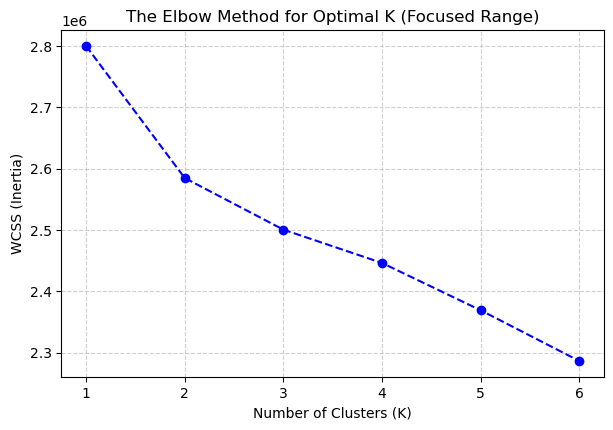

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Calculate WCSS (Inertia) for a more realistic range (1 to 6)
wcss = []
cluster_range = range(1, 7)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# 2. Plot the cleaner Elbow Graph
plt.figure(figsize=(7, 4.5))
plt.plot(cluster_range, wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal K (Focused Range)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(cluster_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [7]:
from sklearn.metrics import silhouette_score

# Evaluate silhouette scores for K=2 and K=3
for k in [2, 3]:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    cluster_labels = kmeans.fit_predict(df_scaled)
    
    # Calculate the average silhouette score
    score = silhouette_score(df_scaled, cluster_labels)
    print(f"Silhouette Score for K={k}: {score:.4f}")

Silhouette Score for K=2: 0.0755
Silhouette Score for K=3: 0.0772


In [8]:
# Fit the final K-Means model with K=3
final_kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df_scaled['Cluster'] = final_kmeans.fit_predict(df_scaled)

# See the distribution of your new segments
print("Product count per cluster:")
print(df_scaled['Cluster'].value_counts())

Product count per cluster:
Cluster
1    23443
2    19505
0     7052
Name: count, dtype: int64


In [11]:
# Map the clusters back to your original unscaled data
df['Cluster'] = df_scaled['Cluster']

# View the real-world averages for each cluster
cluster_profile = df.groupby('Cluster')[['price_usd', 'rating', 'camera_rating', 'performance_rating']].mean()
print(cluster_profile)

          price_usd    rating  camera_rating  performance_rating
Cluster                                                         
0        900.577413  3.108196       2.701929            2.704481
1        655.788009  3.989720       3.519174            3.520795
2        654.460482  2.072187       1.759959            1.762164


## Cluster Interpretation & Personas

---

### 1. Cluster 1: "The Crowd Pleasers" (High Quality, Moderate Price)
* **The Profile:** This is your largest segment (23.4k products). It features a very reasonable average price ($655.79) but has by far the highest satisfaction metrics across the board (Rating: 3.99, Camera: 3.52, Performance: 3.52).
* **The Persona:** High-value, reliable mid-to-high-range devices that consumers absolutely love. Think of these as the "smart buys" or "sweet-spot" phones.

---

### 2. Cluster 0: "The Premium Underperformers" (High Price, Mediocre Quality)
* **The Profile:** This is your smallest segment (7k products). It has the highest average price by a wide margin ($900.58), but the ratings are completely mediocre (Rating: 3.11, Camera/Performance: 2.70).
* **The Persona:** Overpriced premium devices or perhaps older luxury flagships that failed to live up to their price tag, leaving buyers somewhat disappointed.

---

### 3. Cluster 2: "The Budget Traps" (Moderate Price, Poor Quality)
* **The Profile:** This is a huge segment (19.5k products). Price-wise, it costs almost the exact same as your top-tier cluster ($654.46 vs $655.78), but its performance and ratings completely tank (Rating: 2.07, Camera/Performance: 1.76).
* **The Persona:** Products with major quality issues or terrible user experiences despite not being "cheap" in price.

## 📊Observations

---

### 🔍  Value for Money

*   **Cluster 1 vs. Cluster 2 (Price Parity, Massive Quality Gap):**
    > Cluster 1 and Cluster 2 cost almost the exact same amount (~$655). However, Cluster 1 delivers nearly **double the overall rating** (~4.0 vs ~2.0) and vastly superior underlying hardware metrics.
*   **Cluster 0 vs. Cluster 1 & 2 (The Premium Tier):**
    > Cluster 0 exists in an entirely separate financial bracket (~$900+). It is isolated fundamentally by its luxury/premium pricing structure rather than a proportional leap in quality.

---

### 🧠 Performance & Sentiment

*   **Cluster 1 vs. Cluster 2 (Top Tier vs. Lowest Tier):**
    > **Cluster 1** represents the absolute peak performance and user satisfaction across the entire dataset. Conversely, **Cluster 2** represents the worst-performing devices with major quality complaints.
*   **Cluster 0 vs. Cluster 1 & 2 (The Disappointment):**
    > **Cluster 0** captures consumer disappointment. Buyers paid a massive price premium but walked away with significantly lower satisfaction and performance scores than the mid-tier options found in Cluster 1.

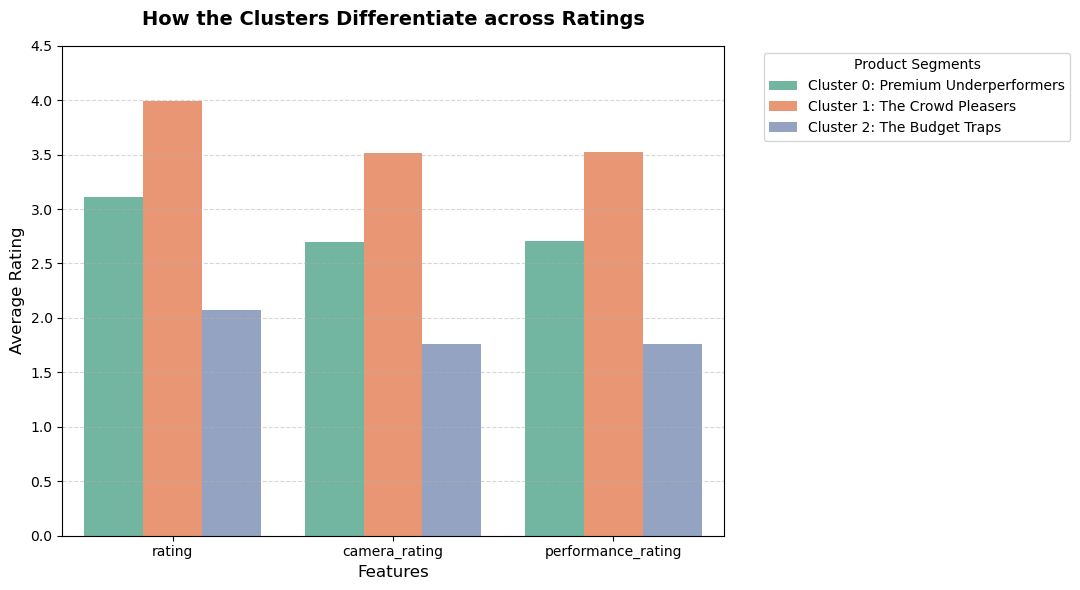

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a copy of the profile so we don't overwrite the original numeric index
profile_named = cluster_profile.copy()

# 2. Map the cluster numbers to your custom names
cluster_mapping = {
    0: 'Cluster 0: Premium Underperformers',
    1: 'Cluster 1: The Crowd Pleasers',
    2: 'Cluster 2: The Budget Traps'
}
profile_named.index = profile_named.index.map(cluster_mapping)

# 3. Reshape the data for easy plotting with seaborn
profile_melted = profile_named.reset_index().melt(
    id_vars='Cluster', 
    value_vars=['rating', 'camera_rating', 'performance_rating']
)

# 4. Generate the plot
plt.figure(figsize=(11, 6))
sns.barplot(data=profile_melted, x='variable', y='value', hue='Cluster', palette='Set2')

# Styling adjustments
plt.title('How the Clusters Differentiate across Ratings', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Average Rating', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.ylim(0, 4.5)  # Gives a little breathing room above the highest bar
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Place the legend in a clean spot
plt.legend(title='Product Segments', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

def get_recommendations(product_id, df_original, df_features, top_n=5):
    """
    Recommends similar products based on a selected product's features within its cluster.
    
    Parameters:
    - product_id: The index or unique identifier of the selected product
    - df_original: The raw/unscaled DataFrame containing readable product names/prices
    - df_features: The scaled feature matrix (df_scaled) used for ML containing the 'Cluster' column
    """
    # 1. Get the cluster of the target product
    target_cluster = df_features.loc[product_id, 'Cluster']
    
    # 2. Filter dataset to include only items from the same cluster
    cluster_indices = df_features[df_features['Cluster'] == target_cluster].index
    
    # 3. Separate features for similarity calculations (dropping the Cluster column itself)
    features_matrix = df_features.loc[cluster_indices].drop(columns=['Cluster'])
    target_features = df_features.loc[[product_id]].drop(columns=['Cluster'])
    
    # 4. Compute Cosine Similarity between target product and its cluster peers
    similarity_scores = cosine_similarity(target_features, features_matrix).flatten()
    
    # 5. Create a mapping of results
    results = pd.DataFrame({
        'Similarity_Score': similarity_scores
    }, index=cluster_indices)
    
    # 6. Sort by highest similarity, exclude the item itself, and pick top_n
    results = results.drop(index=product_id, errors='ignore')
    top_matches = results.sort_values(by='Similarity_Score', ascending=False).head(top_n)
    
    # 7. Pull readable data from original dataframe for validation
    recommendations = df_original.loc[top_matches.index].copy()
    recommendations['Similarity_Score'] = top_matches['Similarity_Score']
    
    # Return the target item details alongside the recommendations
    print(f"--- Target Product (Index {product_id}) ---")
    print(df_original.loc[product_id, ['price_usd', 'rating', 'camera_rating']], "\n")
    
    print(f"--- Top {top_n} Recommended Products ---")
    return recommendations[['price_usd', 'rating', 'camera_rating', 'Similarity_Score']]

# --- TEST THE SYSTEM ---
# Pick any valid index row from your dataset to test (e.g., index 0)
get_recommendations(product_id=0, df_original=df, df_features=df_scaled, top_n=5)

--- Target Product (Index 0) ---
price_usd        337.31
rating             2.00
camera_rating      1.00
Name: 0, dtype: float64 

--- Top 5 Recommended Products ---


,price_usd,rating,camera_rating,Similarity_Score
1205,346.96,2,2,0.975889
49046,225.67,1,1,0.975254
28058,312.50,1,1,0.968144
16390,358.35,2,1,0.967367
32191,325.37,2,1,0.966467


,price_usd,rating,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,Edge 50,...,UAE,UK,USA,AliExpress,Amazon,BestBuy,Flipkart,Unknown_Source,eBay,Cluster
0,337.31,2,1,1,1,3,2,1,1,0,...,0,0,0,0,1,0,0,0,0,2
1,307.78,4,1,3,2,4,3,2,5,0,...,0,0,0,0,0,0,1,0,0,1
2,864.53,4,1,3,5,3,2,4,8,0,...,0,0,0,1,0,0,0,0,0,1
3,660.94,3,0,1,3,2,1,2,3,0,...,1,0,0,0,1,0,0,0,0,2
4,792.13,3,1,3,3,2,2,1,0,1,...,0,0,0,0,0,1,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,526.10,4,0,3,3,4,3,5,4,0,...,0,0,0,0,0,1,0,0,0,1
49996,911.85,3,0,3,2,4,1,3,2,0,...,0,0,0,1,0,0,0,0,0,0
49997,1155.32,3,1,2,3,4,4,5,4,0,...,1,0,0,0,1,0,0,0,0,1
49998,459.04,3,1,1,2,2,1,3,6,0,...,0,0,1,0,0,0,0,1,0,1


In [16]:
df.to_csv('segmented_mobile_products.csv', index=False)